# Activation Patching with Paired RAVDESS Clips

This notebook is the project's final causal-mediation experiment. It addresses the two methodological gaps that remained after notebook 14:

1. All previous interventions used **synthetic centroid directions** (averaged across many training clips). This notebook patches with **actual hidden states** from real source clips.
2. All previous interventions used **single-layer hooks**. This notebook combines those hooks with RAVDESS's controlled pair structure to do **activation patching** in the style of Anthropic's mechanistic interpretability work.

## Why activation patching is the right experiment

RAVDESS is structured as a Latin square: every actor produces every emotion in every sentence at (mostly) every intensity, repeated twice. We can therefore find clip pairs that hold *everything* constant except the emotion &mdash; same actor, same sentence, same intensity, same repetition number, different emotion. Two clips like this are a *natural causal contrast*: any difference in the model's representation between them must reflect emotion, because every other variable is fixed.

For each such pair, we can ask a precise causal question:

> If we swap the destination clip's hidden state at layer $\ell$ with the source clip's hidden state at layer $\ell$, does the destination's output shift toward the source's emotion?

If yes, layer $\ell$ causally carries emotion identity from input to output. This is the cleanest possible mechanistic claim a single-stream forward-pass intervention can make.

## Six experiments

| # | Experiment | Question answered |
|---|---|---|
| 1 | Layer-wise patch transfer | Which layers causally transmit emotion identity? |
| 2 | Patch effect vs centroid-direction effect | Do real-clip patches and synthetic centroid directions agree? |
| 3 | Pair-specific direction vs centroid direction | How well does the population-average direction approximate the actual A&minus;B difference? |
| 4 | Intensity transfer | Can the *strong* version of an emotion be patched into the *normal* version? |
| 5 | Asymmetry of A&rarr;B vs B&rarr;A | Are some emotions easier to inject than others? |
| 6 | Patch controls and component decomposition | Do self/random patches fail, and how much of a real patch is carried by the emotion-direction component? |

Together these answer the strongest version of the question:
> *Where in wav2vec2 is the model's emotion concept stored, and is it stored in a way that supports the kind of causal manipulation that mechanistic interpretability requires?*

## Method (one-screen summary)

For an ordered pair of clips $(s, d)$ with the same context and different emotions:

1. Run $s$ and $d$ through the model. Capture per-layer hidden states $H_\ell^{(s)}, H_\ell^{(d)} \in \mathbb{R}^{T \times 768}$.
2. For each layer $\ell$, register a forward hook on the corresponding wav2vec2 encoder block. The hook overwrites the destination's hidden states at layer $\ell$ with the source's: $H_\ell^{(d)} \leftarrow H_\ell^{(s)}$ (truncating at the destination's actual time length).
3. Re-run the destination forward pass under the hook. Layers $\ell+1 \dots 12$ propagate naturally over the patched activations.
4. Measure how much output probability shifts from emotion $B$ (destination's true label) to emotion $A$ (source's true label).

The headline metric is the **transfer ratio**:

$$
\text{TR}_A(\ell) \;=\; \frac{P(A \mid d_{\text{patched}_\ell}) - P(A \mid d)}{P(A \mid s) - P(A \mid d)}
$$

A value of 0 means the patch had no causal effect; a value of 1 means the patch fully transferred the source's emotion classification onto the destination.

<!-- narrative:15-role -->
## Notebook role in the project

This is the strongest causal-mediation notebook. Instead of adding a synthetic direction, it patches real hidden states from one speech clip into another matched clip and measures whether emotion identity transfers.

**Inputs:** trained checkpoint, test audio, layer-wise directions, and paired RAVDESS metadata.

**Outputs:** layer-wise patch transfer, patch controls, direction-component decomposition, pair-specific analyses, and summary JSON.

**How to read it:** this is the closest speech analogue to an Anthropic-style activation intervention. It shows that real hidden states carry transferable emotion evidence.


In [4]:
from __future__ import annotations

import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/pavannn16/speech-emotion-directions.git"
REPO_NAME = "speech-emotion-directions"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")


def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

IS_COLAB = running_in_colab()
print("Running in Colab:", IS_COLAB)

def run_command(cmd, cwd=None):
    print("+", " ".join(cmd))
    subprocess.check_call(cmd, cwd=str(cwd) if cwd else None)

def ensure_packages():
    pkgs = {"yaml": "pyyaml", "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "torch": "torch", "transformers": "transformers", "sklearn": "scikit-learn", "huggingface_hub": "huggingface_hub", "scipy": "scipy", "tqdm": "tqdm",
            "soundfile": "soundfile", "librosa": "librosa"}
    missing = sorted({p for m, p in pkgs.items() if importlib.util.find_spec(m) is None})
    if missing: run_command([sys.executable, "-m", "pip", "install", "-q", *missing])
    else: print("Required packages available.")

def find_local_project_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd / "FinalProject"]:
        c = c.resolve()
        if (c / "configs" / "wav2vec.yaml").exists() and (c / "src").exists(): return c
    raise FileNotFoundError("Could not find project root.")

def clone_clean(clean_root):
    if clean_root.exists(): shutil.rmtree(clean_root)
    run_command(["git", "clone", "--depth", "1", REPO_URL, str(clean_root)])
    return clean_root

def prepare_roots():
    rt = Path("/content") / REPO_NAME; cl = Path("/content") / f"{REPO_NAME}-clean"
    if rt.exists() and (rt / ".git").exists():
        try: run_command(["git", "-C", str(rt), "fetch", "origin"])
        except: pass
        st = subprocess.run(["git","-C",str(rt),"status","--short"],text=True,capture_output=True,check=True).stdout.splitlines()
        ab = subprocess.run(["git","-C",str(rt),"rev-list","--left-right","--count","HEAD...origin/main"],text=True,capture_output=True,check=False)
        a,b = (0,0) if ab.returncode!=0 or not ab.stdout.strip() else map(int,ab.stdout.strip().split())
        if not [l for l in st if l.strip()] and a==0:
            if b>0:
                try: run_command(["git","-C",str(rt),"pull","--ff-only","origin","main"]); cr=rt
                except: cr=clone_clean(cl)
            else: cr=rt
        else: cr=clone_clean(cl)
        return rt, cr
    elif rt.exists(): return rt, clone_clean(cl)
    else: run_command(["git","clone","--depth","1",REPO_URL,str(rt)]); return rt,rt

ensure_packages()
if IS_COLAB:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT, CODE_ROOT = prepare_roots()
else:
    PROJECT_ROOT = find_local_project_root(); CODE_ROOT = PROJECT_ROOT

os.chdir(PROJECT_ROOT)
for r in [str(CODE_ROOT), str(PROJECT_ROOT)]:
    while r in sys.path: sys.path.remove(r)
sys.path.insert(0, str(CODE_ROOT))
if str(PROJECT_ROOT) != str(CODE_ROOT): sys.path.insert(1, str(PROJECT_ROOT))
for n in [n for n in sys.modules if n == "src" or n.startswith("src.")]: del sys.modules[n]
print("Project root:", PROJECT_ROOT); print("Code root:", CODE_ROOT)


Running in Colab: True
Required packages available.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
+ git -C /content/speech-emotion-directions fetch origin
Project root: /content/speech-emotion-directions
Code root: /content/speech-emotion-directions


In [5]:
experiment_name = 'wav2vec_ravdess_speaker_independent_v1'
local_checkpoint_dir = PROJECT_ROOT / 'artifacts' / 'checkpoints' / experiment_name
local_analysis_dir = PROJECT_ROOT / 'artifacts' / 'analysis' / experiment_name
local_output_dir = local_analysis_dir / 'activation_patching'
local_output_dir.mkdir(parents=True, exist_ok=True)

drive_run_root = Path('/content/drive/MyDrive') / 'speech-emotion-directions' / 'runs' / experiment_name if IS_COLAB else None
drive_checkpoint_dir = drive_run_root / 'checkpoint' if drive_run_root else None
drive_analysis_dir = drive_run_root / 'analysis' if drive_run_root else None
drive_output_dir = drive_analysis_dir / 'activation_patching' if drive_analysis_dir else None

checkpoint_dir = (
    drive_checkpoint_dir
    if drive_checkpoint_dir is not None and (drive_checkpoint_dir / 'model_state.pt').exists()
    else local_checkpoint_dir
)
analysis_source_dir = (
    drive_analysis_dir
    if drive_analysis_dir is not None and (drive_analysis_dir / 'embedding_arrays.npz').exists()
    else local_analysis_dir
)

print('Checkpoint dir:', checkpoint_dir)
print('Analysis dir :', analysis_source_dir)
print('Output dir   :', local_output_dir)


Checkpoint dir: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/checkpoint
Analysis dir : /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis
Output dir   : /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/activation_patching


In [6]:
"""Ensure the RAVDESS test audio is available without slow full-dataset copies.

Notebook 15 only performs fresh model forward passes on the speaker-independent
test actors (21-24). In Colab, if the full RAVDESS cache already exists in Google
Drive, we copy only those four actor folders into /content. That avoids a long
full 1,440-file Drive-to-runtime copy while keeping dataloading fast.
"""
import shutil as _shutil
import zipfile as _zip

RAVDESS_SOURCES = [
    {
        "name": "RAVDESS Speech 16K",
        "url": "https://zenodo.org/api/records/11063852/files/Audio_Speech_Actors_01-24_16k.zip/content",
        "archive_name": "Audio_Speech_Actors_01-24_16k.zip",
    },
    {
        "name": "RAVDESS Speech Original",
        "url": "https://zenodo.org/api/records/1188976/files/Audio_Speech_Actors_01-24.zip/content",
        "archive_name": "Audio_Speech_Actors_01-24.zip",
    },
]

TEST_ACTOR_FOLDERS = [f"Actor_{actor_id:02d}" for actor_id in range(21, 25)]
MIN_TEST_WAVS = 240
MIN_PROJECT_TEST_CLIPS = 208

raw_root = PROJECT_ROOT / "data" / "raw"
extract_dir = raw_root / "ravdess_audio_speech"
metadata_path = PROJECT_ROOT / "data" / "metadata" / "ravdess_metadata.csv"
drive_dataset_dir = (
    Path("/content/drive/MyDrive") / "speech-emotion-directions" / "datasets" / "ravdess_audio_speech"
    if IS_COLAB
    else None
)

raw_root.mkdir(parents=True, exist_ok=True)
metadata_path.parent.mkdir(parents=True, exist_ok=True)


def _count_wavs(root: Path | None, limit: int | None = None) -> int:
    if root is None or not root.exists():
        return 0
    count = 0
    for _ in root.rglob("*.wav"):
        count += 1
        if limit is not None and count >= limit:
            return count
    return count


def _has_test_actor_audio(root: Path | None) -> bool:
    if root is None or not root.exists():
        return False
    return all((root / actor_folder).exists() for actor_folder in TEST_ACTOR_FOLDERS) and _count_wavs(root, MIN_TEST_WAVS) >= MIN_TEST_WAVS


def _has_full_audio(root: Path | None) -> bool:
    return _count_wavs(root, 1440) >= 1440


def _copy_test_actors(source_root: Path, destination_root: Path) -> None:
    destination_root.mkdir(parents=True, exist_ok=True)
    for actor_folder in TEST_ACTOR_FOLDERS:
        source_actor = source_root / actor_folder
        destination_actor = destination_root / actor_folder
        if not source_actor.exists():
            raise FileNotFoundError(f"Drive cache is missing expected actor folder: {source_actor}")
        if destination_actor.exists():
            _shutil.rmtree(destination_actor)
        print(f"Copying {actor_folder} from Drive cache to local runtime...")
        _shutil.copytree(source_actor, destination_actor)


def _restore_test_audio_from_drive_cache() -> bool:
    if drive_dataset_dir is None:
        return False

    if not _has_full_audio(drive_dataset_dir):
        print("Drive RAVDESS cache is missing or incomplete:", drive_dataset_dir)
        return False

    print("Drive RAVDESS cache is available:", drive_dataset_dir)
    if _has_test_actor_audio(extract_dir):
        print("Local runtime already has the required test actor audio.")
        return True

    _copy_test_actors(drive_dataset_dir, extract_dir)
    print("Restored only test actor audio to:", extract_dir)
    return True


def _cache_full_audio_to_drive() -> None:
    if drive_dataset_dir is None or not _has_full_audio(extract_dir):
        return
    if _has_full_audio(drive_dataset_dir):
        print("Google Drive RAVDESS cache already complete:", drive_dataset_dir)
        return
    if drive_dataset_dir.exists():
        _shutil.rmtree(drive_dataset_dir)
    drive_dataset_dir.parent.mkdir(parents=True, exist_ok=True)
    print("Caching full RAVDESS audio in Google Drive for later notebooks...")
    _shutil.copytree(extract_dir, drive_dataset_dir)
    print("Cached RAVDESS audio in Google Drive:", drive_dataset_dir)


def _download_file(url: str, dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        dest.unlink()
    for tool in ["curl", "wget"]:
        import shutil as sh
        if sh.which(tool) is None:
            continue
        cmd = (
            ["curl", "-L", "--fail", "--retry", "3", "--retry-delay", "5", "-A", "Mozilla/5.0", "-o", str(dest), url]
            if tool == "curl"
            else ["wget", "--tries=3", "--waitretry=5", "--user-agent=Mozilla/5.0", "-O", str(dest), url]
        )
        try:
            import subprocess as sp
            print("+", " ".join(cmd))
            sp.check_call(cmd)
            if dest.exists() and dest.stat().st_size > 0:
                return
        except Exception:
            if dest.exists():
                dest.unlink()
    raise RuntimeError(f"Could not download {url}")


def _download_full_ravdess_to_local() -> None:
    downloaded = False
    for src in RAVDESS_SOURCES:
        archive_path = raw_root / src["archive_name"]
        if not (archive_path.exists() and archive_path.stat().st_size > 0):
            try:
                print(f"Downloading {src['name']}...")
                _download_file(src["url"], archive_path)
                downloaded = True
            except RuntimeError as exc:
                print(f"  -> failed: {exc}")
                continue
        else:
            downloaded = True

        if downloaded:
            if extract_dir.exists():
                _shutil.rmtree(extract_dir)
            extract_dir.mkdir(parents=True, exist_ok=True)
            print("Extracting archive...")
            with _zip.ZipFile(archive_path, "r") as zf:
                zf.extractall(extract_dir)
            if _has_full_audio(extract_dir):
                return

    print("Falling back to HuggingFace RAVDESS mirror...")
    from huggingface_hub import snapshot_download
    if extract_dir.exists():
        _shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id="birgermoell/ravdess",
        repo_type="dataset",
        local_dir=extract_dir,
        allow_patterns=["Actor_*/*.wav"],
    )


def _ensure_ravdess_for_notebook_15() -> None:
    print(f"Existing local wav files under {extract_dir}: {_count_wavs(extract_dir)}")

    if _has_test_actor_audio(extract_dir):
        print("Required test actor audio is already local.")
        return

    if _restore_test_audio_from_drive_cache():
        return

    print("No usable Drive cache found; downloading/restoring the full RAVDESS speech dataset locally.")
    _download_full_ravdess_to_local()
    assert _has_test_actor_audio(extract_dir), f"Expected test actor audio under {extract_dir}."
    _cache_full_audio_to_drive()


_ensure_ravdess_for_notebook_15()

from src.data.ravdess_metadata import build_ravdess_metadata, save_metadata
_df = build_ravdess_metadata(extract_dir)
save_metadata(_df, metadata_path)
project_test_count = int(((_df["split"] == "test") & (_df["keep_for_project"])).sum())
assert project_test_count >= MIN_PROJECT_TEST_CLIPS, (
    f"Expected at least {MIN_PROJECT_TEST_CLIPS} kept project test clips, found {project_test_count}."
)

RAW_AUDIO_ROOT = extract_dir
print("Metadata rebuilt at:", metadata_path)
print("RAW_AUDIO_ROOT:", RAW_AUDIO_ROOT, f"({_count_wavs(RAW_AUDIO_ROOT)} wavs)")
print("Project test clips available:", project_test_count)


Existing local wav files under /content/speech-emotion-directions/data/raw/ravdess_audio_speech: 1440
Required test actor audio is already local.
Metadata rebuilt at: /content/speech-emotion-directions/data/metadata/ravdess_metadata.csv
RAW_AUDIO_ROOT: /content/speech-emotion-directions/data/raw/ravdess_audio_speech (1440 wavs)
Project test clips available: 208


In [7]:
import gc
import json
import math

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from src.analysis.advanced_analysis import build_layerwise_directions
from src.analysis.emotion_vectors import (
    build_direction_vectors,
    compute_class_centroids,
    linear_classifier_probabilities,
    load_embedding_artifacts,
    normalize_rows,
)
from src.analysis.extract_embeddings import load_trained_checkpoint
from src.data.dataset import (
    EmotionLabelEncoder,
    RavdessWav2VecDataset,
    Wav2VecCollator,
    load_project_metadata,
)
from src.training.train_wav2vec import (
    get_best_available_device,
    move_batch_to_device,
    resolve_project_path,
)


def release_stale_cuda_objects() -> None:
    """Free common notebook globals before loading a new model copy."""
    for name in [
        'model',
        'checkpoint',
        'base_logits_arr',
        'base_probs_arr',
        'dirs_t',
    ]:
        globals().pop(name, None)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


def choose_memory_safe_device(min_free_gb: float = 3.0) -> torch.device:
    """Use CUDA only when this runtime has enough free memory for wav2vec2."""
    release_stale_cuda_objects()
    if not torch.cuda.is_available():
        print('CUDA is not available; using CPU.')
        return torch.device('cpu')

    try:
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        free_gb = free_bytes / (1024 ** 3)
        total_gb = total_bytes / (1024 ** 3)
        print(f'CUDA memory before model load: {free_gb:.2f} GB free / {total_gb:.2f} GB total')
        if free_gb < min_free_gb:
            print(
                f'CUDA free memory is below {min_free_gb:.1f} GB, so this notebook will use CPU fallback '
                'instead of crashing with an out-of-memory error.'
            )
            return torch.device('cpu')
    except Exception as exc:
        print(f'Could not inspect CUDA memory ({exc}); falling back to the default device selector.')
        return get_best_available_device()

    return torch.device('cuda')


def load_checkpoint_memory_safe(checkpoint_dir, preferred_device: torch.device):
    """Load the fine-tuned model, falling back to CPU if CUDA is too crowded."""
    try:
        return load_trained_checkpoint(checkpoint_dir, device=preferred_device), preferred_device
    except torch.cuda.OutOfMemoryError:
        if preferred_device.type != 'cuda':
            raise
        print('CUDA ran out of memory while loading the checkpoint. Retrying on CPU.')
        release_stale_cuda_objects()
        cpu_device = torch.device('cpu')
        return load_trained_checkpoint(checkpoint_dir, device=cpu_device), cpu_device


# ---------------- cached embedding artifacts ----------------
artifacts = load_embedding_artifacts(analysis_source_dir)
label_names = list(artifacts.summary['label_names'])
reference_label = 'neutral'
reference_idx = label_names.index(reference_label)
num_labels = len(label_names)
num_layer_slots = int(artifacts.layer_embeddings.shape[1])  # 13
num_transformer_layers = num_layer_slots - 1
print(f'Layer slots: {num_layer_slots}, Labels: {label_names}')

# ---------------- model checkpoint ----------------
device = choose_memory_safe_device(min_free_gb=3.0)
print(f'Compute device: {device}')

checkpoint, device = load_checkpoint_memory_safe(checkpoint_dir, preferred_device=device)
model = checkpoint.model
model.eval()
classifier_weight = model.classifier.weight.detach().cpu().numpy()
classifier_bias = model.classifier.bias.detach().cpu().numpy()
hidden_size = int(model.backbone.config.hidden_size)
capture_batch_size = 1 if device.type == 'cpu' else 4
print(f'Capture batch size: {capture_batch_size}')

# ---------------- centroid directions for cross-comparison ----------------
label_ids_full = artifacts.true_label_ids
split_array = artifacts.metadata['split'].to_numpy()
train_mask = split_array == 'train'
test_mask = split_array == 'test'

layerwise_directions_np = build_layerwise_directions(
    layer_embeddings=artifacts.layer_embeddings,
    label_ids=label_ids_full,
    split_mask=train_mask,
    label_names=label_names,
    reference_idx=reference_idx,
)
print(f'Per-layer centroid directions: {layerwise_directions_np.shape}')


Layer slots: 13, Labels: ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
CUDA memory before model load: 39.08 GB free / 39.49 GB total
Compute device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Capture batch size: 4
Per-layer centroid directions: (13, 6, 768)


## 1. Build the paired-clip index

A *context* is a tuple `(actor_id, statement_code, intensity_code, repetition_code)`. Two clips that share a context but differ in emotion form a controlled pair.

For the test set (actors 21-24), we enumerate all ordered pairs `(source, destination)` with shared context and different emotion. We process intensity 01 (normal, includes `neutral`) and intensity 02 (strong, no `neutral`) separately.

**Sanity:** every pair must have `source.emotion != destination.emotion`.

<!-- narrative:15-pair-index -->
## Building controlled clip pairs

A pair is only useful if it controls away obvious confounds. By matching actor, sentence, repetition, and intensity while changing emotion, the patching experiment focuses on emotion identity rather than speaker or lexical content.


In [8]:
import itertools

# Use the metadata that ships with the cached embeddings (has split, actor_id, etc.)
test_metadata = artifacts.metadata[artifacts.metadata['split'] == 'test'].reset_index(drop=True).copy()
test_metadata['_test_idx'] = test_metadata.index  # row index in test split

# Parse intensity_code and repetition_code from RAVDESS filename if not already present.
# Filename format: modality-channel-emotion-intensity-statement-repetition-actor.wav
# e.g. 03-01-05-01-01-02-04.wav -> intensity_code='01', repetition_code='02'
if 'intensity_code' not in test_metadata.columns or 'repetition_code' not in test_metadata.columns:
    def _parse_ravdess_filename(name):
        parts = name.replace('.wav', '').split('-')
        return {'intensity_code': parts[3], 'repetition_code': parts[5]}
    _parsed_parts = test_metadata['file_name'].apply(_parse_ravdess_filename)
    test_metadata['intensity_code'] = [p['intensity_code'] for p in _parsed_parts]
    test_metadata['repetition_code'] = [p['repetition_code'] for p in _parsed_parts]

# Coerce types
for col in ['actor_id', 'statement_code', 'intensity_code', 'repetition_code']:
    if col in test_metadata.columns:
        test_metadata[col] = test_metadata[col].astype(str)

context_keys = ['actor_id', 'statement_code', 'intensity_code', 'repetition_code']
missing = [k for k in context_keys if k not in test_metadata.columns]
if missing:
    raise RuntimeError(f'Missing required metadata columns: {missing}')

# Build label_id from final_label
label_to_id = {n: i for i, n in enumerate(label_names)}
test_metadata['true_label_id'] = test_metadata['final_label'].map(label_to_id).astype(int)

# Build pair index
pair_records = []
for context, group in test_metadata.groupby(context_keys):
    if len(group) < 2:
        continue
    g = group.reset_index(drop=True)
    for i, j in itertools.permutations(range(len(g)), 2):
        if g.loc[i, 'final_label'] == g.loc[j, 'final_label']:
            continue
        pair_records.append({
            'context': '__'.join(context),
            'actor_id': context[0],
            'statement_code': context[1],
            'intensity_code': context[2],
            'repetition_code': context[3],
            'src_test_idx': int(g.loc[i, '_test_idx']),
            'dst_test_idx': int(g.loc[j, '_test_idx']),
            'src_label': g.loc[i, 'final_label'],
            'dst_label': g.loc[j, 'final_label'],
            'src_label_id': int(label_to_id[g.loc[i, 'final_label']]),
            'dst_label_id': int(label_to_id[g.loc[j, 'final_label']]),
        })
pair_df = pd.DataFrame(pair_records)
pair_df.to_csv(local_output_dir / 'pair_index.csv', index=False)
print(f'Total ordered emotion pairs in test set: {len(pair_df)}')
print(pair_df.groupby('intensity_code').size().rename('pairs_count'))
print()
print('Sample pairs:')
display(pair_df.head(10))

Total ordered emotion pairs in test set: 1120
intensity_code
01    640
02    480
Name: pairs_count, dtype: int64

Sample pairs:


,context,actor_id,statement_code,intensity_code,repetition_code,src_test_idx,dst_test_idx,src_label,dst_label,src_label_id,dst_label_id
0,21__1__01__01,21,1,01,01,0,12,neutral,happy,0,1
1,21__1__01__01,21,1,01,01,0,20,neutral,sad,0,2
2,21__1__01__01,21,1,01,01,0,28,neutral,angry,0,3
3,21__1__01__01,21,1,01,01,0,36,neutral,fearful,0,4
4,21__1__01__01,21,1,01,01,0,44,neutral,disgust,0,5
5,21__1__01__01,21,1,01,01,4,12,neutral,happy,0,1
6,21__1__01__01,21,1,01,01,4,20,neutral,sad,0,2
7,21__1__01__01,21,1,01,01,4,28,neutral,angry,0,3
8,21__1__01__01,21,1,01,01,4,36,neutral,fearful,0,4
9,21__1__01__01,21,1,01,01,4,44,neutral,disgust,0,5


## 2. Capture per-clip per-layer hidden states

For activation patching we need each clip's hidden states at every layer, truncated to its actual time length (no padding).

Process: run all 208 test clips through the model in batches, then split each batch's hidden states by the per-clip attention mask so each clip ends up with a list of 13 tensors of shape $(T_i, 768)$ where $T_i$ is the true number of feature frames for clip $i$.

<!-- narrative:15-hidden-states -->
## Capturing hidden states

Activation patching needs hidden states from real clips at each layer. This section prepares the test dataloader and caches those states so later patch loops can reuse them efficiently.


In [9]:
def build_test_dataloader(checkpoint, batch_size=4, raw_audio_root=None):
    metadata_path = resolve_project_path(checkpoint.config['metadata_path'])
    metadata = load_project_metadata(metadata_path, split='test', raw_audio_root=raw_audio_root)
    dataset = RavdessWav2VecDataset(
        metadata=metadata,
        label_encoder=checkpoint.label_encoder,
        sample_rate=int(checkpoint.config['sample_rate']),
    )
    collator = Wav2VecCollator(
        feature_extractor=checkpoint.feature_extractor,
        sample_rate=int(checkpoint.config['sample_rate']),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collator), dataset


capture_loader, capture_dataset = build_test_dataloader(checkpoint, batch_size=capture_batch_size, raw_audio_root=RAW_AUDIO_ROOT)
print(f'Capture loader: {len(capture_loader)} batches')


def capture_per_clip_hidden_states(model, dataloader, device):
    captured = []
    with torch.inference_mode():
        for batch in tqdm(dataloader, desc='capturing'):
            input_values = batch['input_values'].to(device)
            attention_mask = batch.get('attention_mask')
            if attention_mask is not None:
                attention_mask = attention_mask.to(device)

            outputs = model(input_values=input_values,
                            attention_mask=attention_mask,
                            output_hidden_states=True)

            T_padded = outputs.hidden_states[0].shape[1]
            if attention_mask is not None and hasattr(model.backbone, '_get_feature_vector_attention_mask'):
                feat_mask = model.backbone._get_feature_vector_attention_mask(T_padded, attention_mask)
            else:
                feat_mask = torch.ones(input_values.shape[0], T_padded, device=device)

            B = outputs.logits.shape[0]
            for b in range(B):
                valid_T = int(feat_mask[b].sum().item())
                clip_layers = [h[b, :valid_T].detach().cpu().clone() for h in outputs.hidden_states]
                captured.append({
                    'hidden_states': clip_layers,                # list[13] of (T_b, 768) cpu tensors
                    'logits': outputs.logits[b].detach().cpu().clone(),
                    'pred_label_id': int(outputs.logits[b].argmax().item()),
                    'true_label_id': int(batch['labels'][b].item()),
                    'valid_T': valid_T,
                    'metadata': batch['metadata'][b],
                })
    return captured


cached_clips = capture_per_clip_hidden_states(model, capture_loader, device)
assert len(cached_clips) == len(test_metadata), f'expected {len(test_metadata)}, got {len(cached_clips)}'
print(f'Captured {len(cached_clips)} clips. Layer slots per clip: {len(cached_clips[0]["hidden_states"])}.')
print(f'First-clip valid_T: {cached_clips[0]["valid_T"]}')

# Build per-clip baseline probability table for fast lookup
def softmax_np(logits):
    z = logits - logits.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.clip(e.sum(axis=-1, keepdims=True), 1e-12, None)

base_logits_arr = np.stack([c['logits'].numpy() for c in cached_clips], axis=0)
base_probs_arr = softmax_np(base_logits_arr)

# Sanity vs cached probabilities in artifacts (should match closely)
test_base_probs_arr = base_probs_arr  # aligned with test_metadata index since dataloader and metadata are both ordered
print(f'Per-clip baseline accuracy (forward pass on captured audio): '
      f'{accuracy_score(test_metadata["true_label_id"], base_probs_arr.argmax(axis=1)):.4f}')


Capture loader: 52 batches


capturing:   0%|          | 0/52 [00:00<?, ?it/s]

Captured 208 clips. Layer slots per clip: 13.
First-clip valid_T: 198
Per-clip baseline accuracy (forward pass on captured audio): 0.8173


## 3. Patch-intervention infrastructure

`PatchIntervention` is a hook that overwrites the destination's hidden states at layer $\ell$ with the source's hidden states at layer $\ell$, position-by-position, up to the destination's actual time length.

Rules:

- If $T_s \ge T_d$: the entire destination layer-$\ell$ output is replaced.
- If $T_s < T_d$: only the first $T_s$ destination tokens are replaced; the trailing $T_d - T_s$ tokens are left as the destination's natural values.

Trailing tokens that the source can't supply are preserved from the destination, so the patch is well-defined under arbitrary length mismatch. Mean-pooling at the end uses the destination's attention mask, so padding positions never contribute regardless.

<!-- narrative:15-patch-hook -->
## Patch hook infrastructure

The patch hook replaces the destination hidden state with the source hidden state at a selected layer. If the output moves toward the source emotion after the remaining layers run, the patched state carried causal emotion evidence.


In [10]:
class PatchIntervention:
    """Forward hook that overwrites a wav2vec2 encoder layer's output with a provided
    (T_src, hidden_size) tensor. Length mismatches are handled by truncation/preservation.

    layer_index follows the project convention:
      0    -> forward_pre_hook on encoder.layers[0] (input to encoder)
      1..12 -> forward_hook on encoder.layers[layer_index - 1]
    """

    def __init__(self, model, layer_index, src_hidden_at_layer):
        n_layers = len(model.backbone.encoder.layers)
        if not (0 <= layer_index <= n_layers):
            raise ValueError(f'layer_index out of [0, {n_layers}]')
        if src_hidden_at_layer.dim() != 2:
            raise ValueError(f'src_hidden must be 2-D (T, H); got {tuple(src_hidden_at_layer.shape)}')
        self.model = model
        self.layer_index = int(layer_index)
        self.src_hidden = src_hidden_at_layer.detach()
        self.handle = None

    def _post_hook(self, module, inputs, output):
        if isinstance(output, tuple):
            hidden = output[0]
        else:
            hidden = output
        new_hidden = hidden.clone()
        T_dst = new_hidden.shape[1]
        T_src = self.src_hidden.shape[0]
        fill = min(T_dst, T_src)
        new_hidden[:, :fill, :] = self.src_hidden[:fill].to(new_hidden.dtype).to(new_hidden.device).unsqueeze(0)
        if isinstance(output, tuple):
            return (new_hidden,) + tuple(output[1:])
        return new_hidden

    def _pre_hook(self, module, inputs):
        hidden = inputs[0]
        new_hidden = hidden.clone()
        T_dst = new_hidden.shape[1]
        T_src = self.src_hidden.shape[0]
        fill = min(T_dst, T_src)
        new_hidden[:, :fill, :] = self.src_hidden[:fill].to(new_hidden.dtype).to(new_hidden.device).unsqueeze(0)
        return (new_hidden,) + tuple(inputs[1:])

    def __enter__(self):
        if self.layer_index == 0:
            self.handle = self.model.backbone.encoder.layers[0].register_forward_pre_hook(self._pre_hook)
        else:
            self.handle = self.model.backbone.encoder.layers[self.layer_index - 1].register_forward_hook(self._post_hook)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        if self.handle is not None:
            self.handle.remove()
            self.handle = None


def run_patched_destination(model, dst_dataset, dst_test_idx, src_hidden_at_layer, layer_index, device):
    """Re-run the destination clip through the model with a patch hook at layer_index.
    Returns logits of shape (num_labels,).
    """
    item = dst_dataset[dst_test_idx]
    audio = torch.tensor(item['audio'], dtype=torch.float32).unsqueeze(0)
    attention_mask = torch.ones_like(audio)
    audio = audio.to(device)
    attention_mask = attention_mask.to(device)

    intervention = PatchIntervention(model, layer_index, src_hidden_at_layer)
    with torch.inference_mode(), intervention:
        out = model(input_values=audio, attention_mask=attention_mask)
    return out.logits[0].detach().cpu().numpy()

## 4. Experiment 1 &mdash; Layer-wise patch transfer

For every ordered pair $(s, d)$ and every layer $\ell \in [0, 12]$, patch the destination's layer-$\ell$ hidden states with the source's layer-$\ell$ hidden states. Record:

- `delta_p_src`: $P(A \mid d_{\text{patched}}) - P(A \mid d)$ &mdash; how much source-emotion probability rose in the destination.
- `delta_p_dst`: $P(B \mid d_{\text{patched}}) - P(B \mid d)$ &mdash; how much destination-emotion probability fell.
- `transfer_ratio`: normalized $\text{TR}_A(\ell)$ as defined in the intro &mdash; bounded to roughly $[0, 1]$ when patching has the predicted causal direction.
- `flip_to_src`: whether $\arg\max P(\cdot \mid d_{\text{patched}}) = A$.

We aggregate by layer to get the **causal mediation curve**.

<!-- narrative:15-layer-sweep -->
## Layer-wise patch transfer

This is the main patching experiment. It sweeps over layers and measures how much the destination output shifts toward the source emotion. The best layer identifies where hidden states are most transferable.


In [11]:
# To keep runtime tractable we sample contexts (subsample by repetition_code).
# All ordered pairs at intensity 01 (normal) get used; we then run the layer sweep.

PATCH_INTENSITY = '01'  # normal intensity (includes neutral)
patch_subset = pair_df[pair_df['intensity_code'] == PATCH_INTENSITY].reset_index(drop=True).copy()
print(f'Pairs to process: {len(patch_subset)}  (intensity {PATCH_INTENSITY})')

LAYER_SWEEP = list(range(num_layer_slots))  # 0..12
print(f'Layers to sweep: {LAYER_SWEEP}')


def patched_logits_for_pair(src_idx, dst_idx, layer_index):
    src_hidden = cached_clips[src_idx]['hidden_states'][layer_index].to(device)
    return run_patched_destination(model, capture_dataset, dst_idx, src_hidden, layer_index, device)


# Precompute baseline P(A|d), P(B|d), P(A|s) needed for transfer ratio
records = []
total = len(patch_subset) * len(LAYER_SWEEP)
pbar = tqdm(total=total, desc='patch sweep')
for _, pair in patch_subset.iterrows():
    s_idx, d_idx = pair['src_test_idx'], pair['dst_test_idx']
    A, B = pair['src_label_id'], pair['dst_label_id']
    p_dst_baseline = base_probs_arr[d_idx]
    p_src_baseline = base_probs_arr[s_idx]
    p_A_d = float(p_dst_baseline[A]); p_B_d = float(p_dst_baseline[B])
    p_A_s = float(p_src_baseline[A]); p_B_s = float(p_src_baseline[B])

    for layer_idx in LAYER_SWEEP:
        patched_logits = patched_logits_for_pair(int(s_idx), int(d_idx), layer_idx)
        patched_probs = softmax_np(patched_logits)
        p_A_p = float(patched_probs[A]); p_B_p = float(patched_probs[B])

        denom_A = max(p_A_s - p_A_d, 1e-6) if p_A_s > p_A_d else min(p_A_s - p_A_d, -1e-6)
        denom_B = max(p_B_d - p_B_s, 1e-6) if p_B_d > p_B_s else min(p_B_d - p_B_s, -1e-6)
        records.append({
            'context': pair['context'],
            'src_label': pair['src_label'], 'dst_label': pair['dst_label'],
            'src_idx': int(s_idx), 'dst_idx': int(d_idx),
            'layer_index': int(layer_idx),
            'p_A_d': p_A_d, 'p_B_d': p_B_d,
            'p_A_s': p_A_s, 'p_B_s': p_B_s,
            'p_A_patched': p_A_p, 'p_B_patched': p_B_p,
            'delta_p_src': p_A_p - p_A_d,
            'delta_p_dst': p_B_p - p_B_d,
            'transfer_ratio_src': (p_A_p - p_A_d) / denom_A,
            'transfer_ratio_dst': (p_B_d - p_B_p) / denom_B,
            'flip_to_src': bool(int(patched_probs.argmax()) == A),
        })
        pbar.update(1)
pbar.close()

patch_df = pd.DataFrame(records)
patch_df.to_csv(local_output_dir / 'experiment_1_patch_sweep.csv', index=False)
print(f'\nPatch sweep records: {len(patch_df)}')
display(patch_df.head(8).round(4))

Pairs to process: 640  (intensity 01)
Layers to sweep: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


patch sweep:   0%|          | 0/8320 [00:00<?, ?it/s]


Patch sweep records: 8320


,context,src_label,dst_label,src_idx,dst_idx,layer_index,p_A_d,p_B_d,p_A_s,p_B_s,p_A_patched,p_B_patched,delta_p_src,delta_p_dst,transfer_ratio_src,transfer_ratio_dst,flip_to_src
0,21__1__01__01,neutral,happy,0,12,0,0.0373,0.9404,0.9647,0.0195,0.9706,0.0144,0.9333,-0.9260,1.0064,1.0056,True
1,21__1__01__01,neutral,happy,0,12,1,0.0373,0.9404,0.9647,0.0195,0.9706,0.0144,0.9334,-0.9260,1.0064,1.0055,True
2,21__1__01__01,neutral,happy,0,12,2,0.0373,0.9404,0.9647,0.0195,0.9616,0.0219,0.9243,-0.9185,0.9967,0.9974,True
3,21__1__01__01,neutral,happy,0,12,3,0.0373,0.9404,0.9647,0.0195,0.9554,0.0271,0.9182,-0.9133,0.9900,0.9918,True
4,21__1__01__01,neutral,happy,0,12,4,0.0373,0.9404,0.9647,0.0195,0.9543,0.0280,0.9170,-0.9124,0.9888,0.9908,True
5,21__1__01__01,neutral,happy,0,12,5,0.0373,0.9404,0.9647,0.0195,0.9566,0.0261,0.9193,-0.9143,0.9913,0.9928,True
6,21__1__01__01,neutral,happy,0,12,6,0.0373,0.9404,0.9647,0.0195,0.9555,0.0271,0.9182,-0.9133,0.9901,0.9918,True
7,21__1__01__01,neutral,happy,0,12,7,0.0373,0.9404,0.9647,0.0195,0.9535,0.0289,0.9162,-0.9116,0.9879,0.9899,True


,layer_index,mean_delta_p_src,median_delta_p_src,mean_transfer_ratio_src,median_transfer_ratio_src,mean_delta_p_dst,flip_rate
0,0,0.6689,0.9399,1.0934,0.9999,-0.6783,0.7406
1,1,0.6652,0.9382,1.0405,0.9998,-0.6781,0.7359
2,2,0.6657,0.9376,1.0380,0.9996,-0.6781,0.7453
3,3,0.6645,0.9367,1.0080,0.9993,-0.6779,0.7375
4,4,0.6649,0.9363,1.0233,0.9994,-0.6770,0.7359
5,5,0.6622,0.9367,1.0072,0.9994,-0.6762,0.7375
6,6,0.6647,0.9359,1.0158,0.9994,-0.6749,0.7328
7,7,0.6715,0.9380,1.0176,0.9995,-0.6765,0.7406
8,8,0.6738,0.9370,1.0229,0.9995,-0.6766,0.7453
9,9,0.6768,0.9399,1.0262,0.9996,-0.6788,0.7500


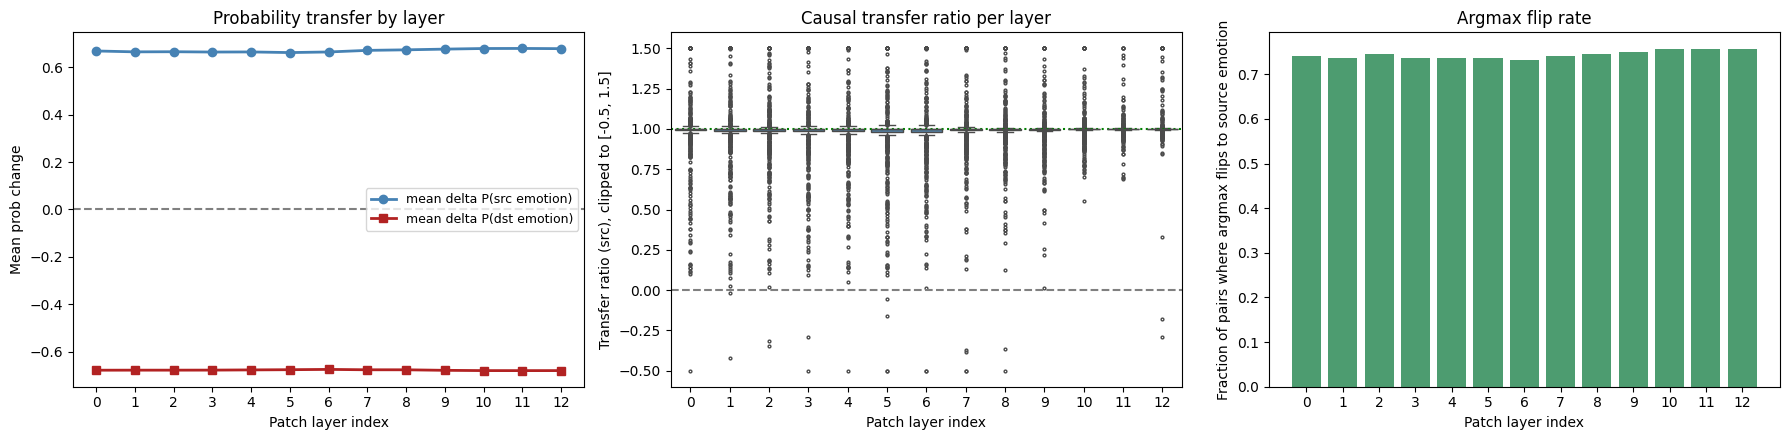


Best patch layer (by mean delta P(src)): 11
Argmax flip rate at that layer: 0.7562


In [12]:
# Aggregate by layer
agg_by_layer = patch_df.groupby('layer_index').agg(
    mean_delta_p_src=('delta_p_src', 'mean'),
    median_delta_p_src=('delta_p_src', 'median'),
    mean_transfer_ratio_src=('transfer_ratio_src', 'mean'),
    median_transfer_ratio_src=('transfer_ratio_src', 'median'),
    mean_delta_p_dst=('delta_p_dst', 'mean'),
    flip_rate=('flip_to_src', 'mean'),
).reset_index()
agg_by_layer.to_csv(local_output_dir / 'experiment_1_layer_aggregates.csv', index=False)
display(agg_by_layer.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Panel 1: Delta P(source emotion) by layer
ax = axes[0]
ax.plot(agg_by_layer['layer_index'], agg_by_layer['mean_delta_p_src'],
        marker='o', color='steelblue', linewidth=2, label='mean delta P(src emotion)')
ax.plot(agg_by_layer['layer_index'], agg_by_layer['mean_delta_p_dst'],
        marker='s', color='firebrick', linewidth=2, label='mean delta P(dst emotion)')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xticks(LAYER_SWEEP)
ax.set_xlabel('Patch layer index')
ax.set_ylabel('Mean prob change')
ax.set_title('Probability transfer by layer')
ax.legend(fontsize=9)

# Panel 2: Transfer ratio (clipped for visualization)
ax = axes[1]
clipped_tr = patch_df.copy()
clipped_tr['transfer_ratio_src_clipped'] = clipped_tr['transfer_ratio_src'].clip(-0.5, 1.5)
sns.boxplot(data=clipped_tr, x='layer_index', y='transfer_ratio_src_clipped',
            ax=ax, color='steelblue', fliersize=2)
ax.axhline(0, color='gray', linestyle='--')
ax.axhline(1, color='green', linestyle=':')
ax.set_xlabel('Patch layer index')
ax.set_ylabel('Transfer ratio (src), clipped to [-0.5, 1.5]')
ax.set_title('Causal transfer ratio per layer')

# Panel 3: Flip rate
ax = axes[2]
ax.bar(agg_by_layer['layer_index'], agg_by_layer['flip_rate'],
       color='seagreen', alpha=0.85)
ax.set_xticks(LAYER_SWEEP)
ax.set_xlabel('Patch layer index')
ax.set_ylabel('Fraction of pairs where argmax flips to source emotion')
ax.set_title('Argmax flip rate')

plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_1_patch_layer_curves.png', dpi=220)
plt.show()

best_patch_layer = int(agg_by_layer.loc[agg_by_layer['mean_delta_p_src'].idxmax(), 'layer_index'])
print(f'\nBest patch layer (by mean delta P(src)): {best_patch_layer}')
print(f'Argmax flip rate at that layer: {float(agg_by_layer.loc[agg_by_layer["layer_index"] == best_patch_layer, "flip_rate"].iloc[0]):.4f}')

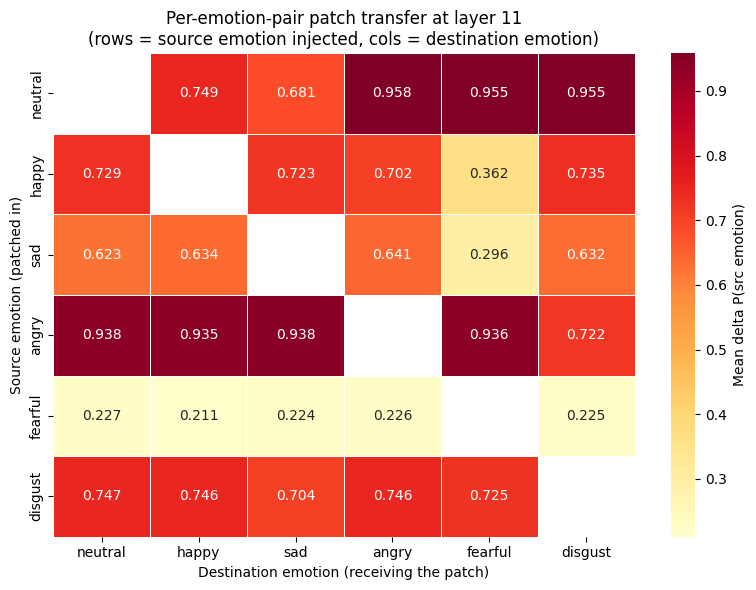

In [13]:
# Per-emotion-pair heatmap at the best layer: which (src, dst) pairs transfer well?
best_layer_df = patch_df[patch_df['layer_index'] == best_patch_layer]
heatmap_pivot = (best_layer_df
                 .groupby(['src_label', 'dst_label'])['delta_p_src']
                 .mean().unstack(fill_value=np.nan)
                 .reindex(index=label_names, columns=label_names))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.4, cbar_kws={'label': 'Mean delta P(src emotion)'})
ax.set_title(f'Per-emotion-pair patch transfer at layer {best_patch_layer}\n(rows = source emotion injected, cols = destination emotion)')
ax.set_ylabel('Source emotion (patched in)')
ax.set_xlabel('Destination emotion (receiving the patch)')
plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_1_pair_heatmap.png', dpi=220)
plt.show()

## 5. Experiment 2 &mdash; Patch effect vs centroid-direction effect

The earlier notebooks (07, 09, 12, 14) used **centroid directions** $\mathbf{d}_\ell^{(c)} = \mu_c^\ell - \mu_{\text{neutral}}^\ell$. This experiment tests whether those synthetic directions agree with what an actual source clip's hidden state would do, by comparing two interventions on each destination at the same layer:

- **Patch** (this notebook): replace destination's layer-$\ell$ hidden state with the source's actual layer-$\ell$ hidden state.
- **Direction add** (nb 14): add $\alpha \, \mathbf{d}_\ell^{(A)}$ to destination's layer-$\ell$ hidden state (broadcast over time).

If the centroid direction is a good summary of "the typical hidden-state difference between $A$ and neutral," its effect should correlate with the per-clip patch effect.

<!-- narrative:15-centroid-vs-patch -->
## Real patch vs centroid-direction edit

This comparison asks whether a synthetic centroid direction explains the same effect as a real hidden-state patch. The result is intentionally nuanced: centroid directions are powerful, but real patches carry richer pair-specific structure.


In [14]:
# Reuse PatchIntervention's add-mode behavior via a small helper
class AddDirectionIntervention:
    def __init__(self, model, layer_index, direction_vec, alpha):
        self.model = model; self.layer_index = layer_index
        self.direction = direction_vec; self.alpha = float(alpha); self.handle = None

    def _post_hook(self, module, inputs, output):
        scaled = self.alpha * self.direction
        if isinstance(output, tuple):
            hidden = output[0]
            return (hidden + scaled[None, None, :].to(hidden.dtype).to(hidden.device),) + tuple(output[1:])
        return output + scaled[None, None, :].to(output.dtype).to(output.device)

    def _pre_hook(self, module, inputs):
        scaled = self.alpha * self.direction
        hidden = inputs[0]
        return (hidden + scaled[None, None, :].to(hidden.dtype).to(hidden.device),) + tuple(inputs[1:])

    def __enter__(self):
        if self.layer_index == 0:
            self.handle = self.model.backbone.encoder.layers[0].register_forward_pre_hook(self._pre_hook)
        else:
            self.handle = self.model.backbone.encoder.layers[self.layer_index - 1].register_forward_hook(self._post_hook)
        return self

    def __exit__(self, *a):
        if self.handle is not None:
            self.handle.remove(); self.handle = None


def run_with_direction_add(model, dst_dataset, dst_test_idx, direction_t, alpha, layer_index, device):
    item = dst_dataset[dst_test_idx]
    audio = torch.tensor(item['audio'], dtype=torch.float32).unsqueeze(0).to(device)
    attention_mask = torch.ones_like(audio).to(device)
    intervention = AddDirectionIntervention(model, layer_index, direction_t, alpha)
    with torch.inference_mode(), intervention:
        out = model(input_values=audio, attention_mask=attention_mask)
    return out.logits[0].detach().cpu().numpy()


# Use alpha=0.5 to match notebook 14's sweep
ALPHA_FOR_COMPARISON = 0.5
dirs_t = torch.from_numpy(layerwise_directions_np).to(device).float()

cmp_records = []
unique_pairs_at_best = patch_subset.copy()
pbar = tqdm(total=len(unique_pairs_at_best), desc=f'patch vs direction at layer {best_patch_layer}')
for _, pair in unique_pairs_at_best.iterrows():
    s_idx, d_idx = pair['src_test_idx'], pair['dst_test_idx']
    A = pair['src_label_id']

    # Patch effect
    src_hidden = cached_clips[s_idx]['hidden_states'][best_patch_layer].to(device)
    patch_logits = run_patched_destination(model, capture_dataset, int(d_idx), src_hidden, best_patch_layer, device)
    patch_probs = softmax_np(patch_logits)

    # Direction-add effect (centroid direction for emotion A)
    dir_vec = dirs_t[best_patch_layer, A]
    dir_logits = run_with_direction_add(model, capture_dataset, int(d_idx), dir_vec, ALPHA_FOR_COMPARISON, best_patch_layer, device)
    dir_probs = softmax_np(dir_logits)

    cmp_records.append({
        'src_label': pair['src_label'], 'dst_label': pair['dst_label'],
        'src_idx': int(s_idx), 'dst_idx': int(d_idx),
        'patch_delta_p_src': float(patch_probs[A] - base_probs_arr[d_idx, A]),
        'direction_delta_p_src': float(dir_probs[A] - base_probs_arr[d_idx, A]),
        'patch_argmax_match_src': bool(int(patch_probs.argmax()) == A),
        'direction_argmax_match_src': bool(int(dir_probs.argmax()) == A),
    })
    pbar.update(1)
pbar.close()

cmp_df = pd.DataFrame(cmp_records)
cmp_df.to_csv(local_output_dir / 'experiment_2_patch_vs_direction.csv', index=False)
print(f'\nPatch vs direction comparison: {len(cmp_df)} pairs at layer {best_patch_layer}, alpha={ALPHA_FOR_COMPARISON}')
display(cmp_df.head(8).round(4))

# Pearson and Spearman correlation of effects
from scipy.stats import pearsonr, spearmanr
r_pearson, _ = pearsonr(cmp_df['patch_delta_p_src'], cmp_df['direction_delta_p_src'])
r_spearman, _ = spearmanr(cmp_df['patch_delta_p_src'], cmp_df['direction_delta_p_src'])
print(f'Pearson r  (patch vs direction effects): {r_pearson:.4f}')
print(f'Spearman r (patch vs direction effects): {r_spearman:.4f}')

patch vs direction at layer 11:   0%|          | 0/640 [00:00<?, ?it/s]


Patch vs direction comparison: 640 pairs at layer 11, alpha=0.5


,src_label,dst_label,src_idx,dst_idx,patch_delta_p_src,direction_delta_p_src,patch_argmax_match_src,direction_argmax_match_src
0,neutral,happy,0,12,0.9273,-0.0112,True,False
1,neutral,sad,0,20,0.9371,0.0069,True,False
2,neutral,angry,0,28,0.9558,0.0000,True,False
3,neutral,fearful,0,36,0.9614,-0.0002,True,False
4,neutral,disgust,0,44,0.9599,0.0003,True,False
5,neutral,happy,4,12,0.9473,-0.0112,True,False
6,neutral,sad,4,20,0.9576,0.0069,True,False
7,neutral,angry,4,28,0.9824,0.0000,True,False


Pearson r  (patch vs direction effects): -0.0096
Spearman r (patch vs direction effects): -0.0629


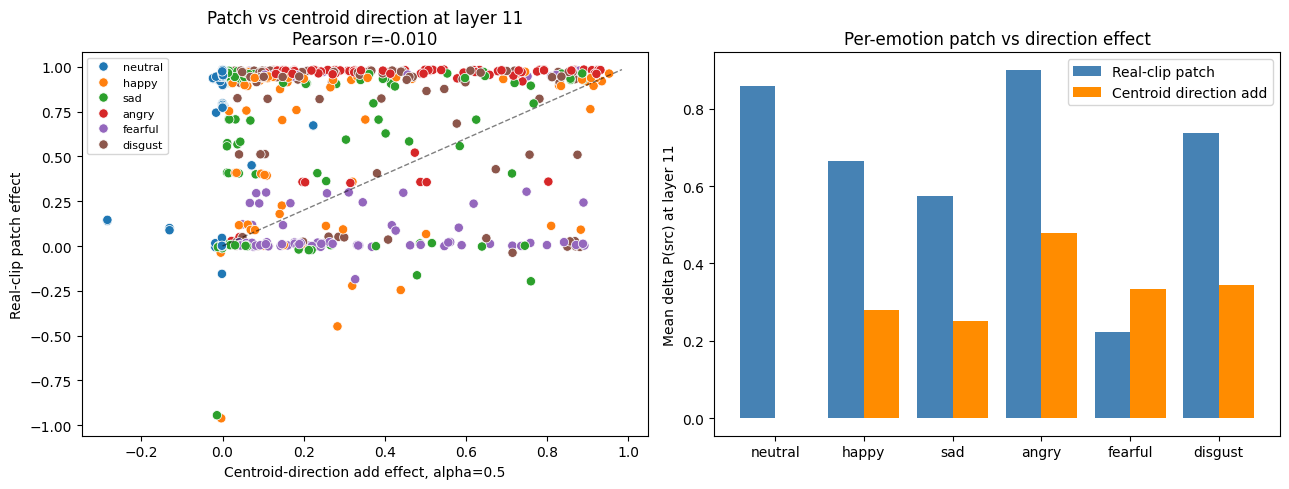

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
sns.scatterplot(data=cmp_df, x='direction_delta_p_src', y='patch_delta_p_src',
                hue='src_label', s=45, ax=ax)
m = max(cmp_df['direction_delta_p_src'].max(), cmp_df['patch_delta_p_src'].max())
ax.plot([0, m], [0, m], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel(f'Centroid-direction add effect, alpha={ALPHA_FOR_COMPARISON}')
ax.set_ylabel('Real-clip patch effect')
ax.set_title(f'Patch vs centroid direction at layer {best_patch_layer}\nPearson r={r_pearson:.3f}')
ax.legend(loc='best', fontsize=8)

# Per-emotion bars
ax = axes[1]
agg = cmp_df.groupby('src_label').agg(
    patch=('patch_delta_p_src', 'mean'),
    direction=('direction_delta_p_src', 'mean'),
).reindex(label_names).dropna()
x = np.arange(len(agg))
w = 0.4
ax.bar(x - w/2, agg['patch'], w, label='Real-clip patch', color='steelblue')
ax.bar(x + w/2, agg['direction'], w, label='Centroid direction add', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(agg.index)
ax.set_ylabel(f'Mean delta P(src) at layer {best_patch_layer}')
ax.set_title('Per-emotion patch vs direction effect')
ax.legend()

plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_2_patch_vs_direction.png', dpi=220)
plt.show()

## 6. Experiment 3 &mdash; Pair-specific direction analysis

For each pair $(s, d)$, the *actual* hidden-state difference at layer $\ell$ is

$$
\Delta_\ell^{(s, d)} \;=\; \bar{H}_\ell^{(s)} - \bar{H}_\ell^{(d)},
$$

where $\bar{H}$ is the mean-pool over the clip's valid time positions. This is the direction the model would *actually* need to traverse to convert this destination into this source. We compare it to the centroid direction $\mathbf{d}_\ell^{(A)} - \mathbf{d}_\ell^{(B)}$ (the population-level analog).

If the centroid direction is a good population summary, the cosine similarity between $\Delta_\ell^{(s, d)}$ and the corresponding centroid contrast should be high &mdash; especially in the layers where mid-transformer interventions had the largest behavioral effect.

<!-- narrative:15-pair-specific -->
## Pair-specific direction analysis

This section compares actual source-destination hidden-state differences with population centroid directions. It helps avoid overclaiming that all emotion information is captured by one averaged vector.


In [16]:
def mean_pool(h):
    return h.mean(dim=0).numpy() if isinstance(h, torch.Tensor) else h.mean(axis=0)

def safe_cos(a, b, eps=1e-12):
    na = float(np.linalg.norm(a)); nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return float('nan')
    return float(np.dot(a, b) / (na * nb))


pair_dir_records = []
for _, pair in tqdm(patch_subset.iterrows(), total=len(patch_subset), desc='pair directions'):
    s_idx, d_idx = pair['src_test_idx'], pair['dst_test_idx']
    A, B = pair['src_label_id'], pair['dst_label_id']
    for layer_idx in LAYER_SWEEP:
        delta_pair = mean_pool(cached_clips[s_idx]['hidden_states'][layer_idx]) - \
                     mean_pool(cached_clips[d_idx]['hidden_states'][layer_idx])
        centroid_contrast = layerwise_directions_np[layer_idx, A] - layerwise_directions_np[layer_idx, B]

        pair_dir_records.append({
            'src_label': pair['src_label'], 'dst_label': pair['dst_label'],
            'src_idx': int(s_idx), 'dst_idx': int(d_idx),
            'layer_index': int(layer_idx),
            'pair_norm':       float(np.linalg.norm(delta_pair)),
            'centroid_norm':   float(np.linalg.norm(centroid_contrast)),
            'cosine_to_centroid': safe_cos(delta_pair, centroid_contrast),
            'cosine_to_src_centroid': safe_cos(delta_pair, layerwise_directions_np[layer_idx, A]),
        })

pair_dir_df = pd.DataFrame(pair_dir_records)
pair_dir_df.to_csv(local_output_dir / 'experiment_3_pair_directions.csv', index=False)
display(pair_dir_df.head(8).round(4))

agg_dir = pair_dir_df.groupby('layer_index').agg(
    mean_cosine_to_centroid=('cosine_to_centroid', 'mean'),
    median_cosine_to_centroid=('cosine_to_centroid', 'median'),
    mean_pair_norm=('pair_norm', 'mean'),
    mean_centroid_norm=('centroid_norm', 'mean'),
).reset_index()
display(agg_dir.round(4))

pair directions:   0%|          | 0/640 [00:00<?, ?it/s]

,src_label,dst_label,src_idx,dst_idx,layer_index,pair_norm,centroid_norm,cosine_to_centroid,cosine_to_src_centroid
0,neutral,happy,0,12,0,2.1161,0.8560,-0.0528,NaN
1,neutral,happy,0,12,1,1.7914,0.8253,0.1061,NaN
2,neutral,happy,0,12,2,1.5532,0.9679,0.1966,NaN
3,neutral,happy,0,12,3,1.4418,1.2412,0.2495,NaN
4,neutral,happy,0,12,4,1.3597,1.6918,0.1864,NaN
5,neutral,happy,0,12,5,1.4100,2.1447,0.3074,NaN
6,neutral,happy,0,12,6,1.4877,2.6888,0.3303,NaN
7,neutral,happy,0,12,7,1.7168,3.2940,0.3923,NaN


,layer_index,mean_cosine_to_centroid,median_cosine_to_centroid,mean_pair_norm,mean_centroid_norm
0,0,0.2673,0.2841,1.7589,0.6973
1,1,0.2665,0.2900,1.5154,0.6633
2,2,0.2941,0.3183,1.5970,0.8058
3,3,0.3354,0.3541,1.7455,1.0468
4,4,0.4047,0.4364,2.0471,1.4509
5,5,0.4863,0.5085,2.5748,2.1192
6,6,0.5435,0.5707,3.0809,2.9124
7,7,0.5840,0.6199,3.7960,4.1145
8,8,0.6140,0.6372,4.5246,5.2655
9,9,0.6581,0.7036,5.4446,6.6836


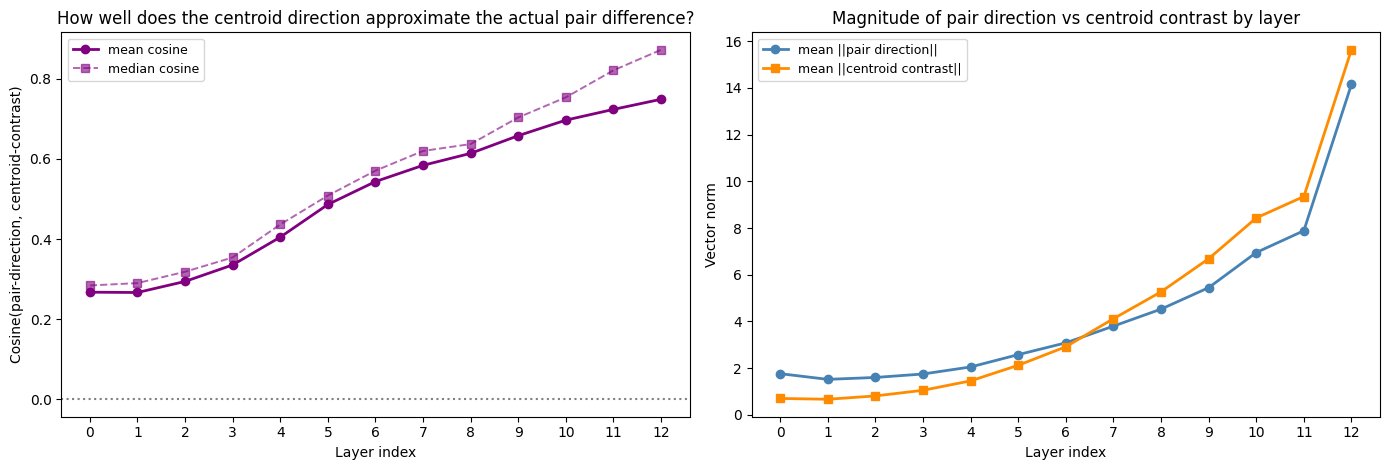

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.plot(agg_dir['layer_index'], agg_dir['mean_cosine_to_centroid'],
        marker='o', linewidth=2, color='purple', label='mean cosine')
ax.plot(agg_dir['layer_index'], agg_dir['median_cosine_to_centroid'],
        marker='s', linewidth=1.4, linestyle='--', color='purple', alpha=0.6, label='median cosine')
ax.set_xticks(LAYER_SWEEP)
ax.set_xlabel('Layer index')
ax.set_ylabel('Cosine(pair-direction, centroid-contrast)')
ax.set_title('How well does the centroid direction approximate the actual pair difference?')
ax.axhline(0, color='gray', linestyle=':')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(agg_dir['layer_index'], agg_dir['mean_pair_norm'],
        marker='o', linewidth=2, color='steelblue', label='mean ||pair direction||')
ax.plot(agg_dir['layer_index'], agg_dir['mean_centroid_norm'],
        marker='s', linewidth=2, color='darkorange', label='mean ||centroid contrast||')
ax.set_xticks(LAYER_SWEEP)
ax.set_xlabel('Layer index')
ax.set_ylabel('Vector norm')
ax.set_title('Magnitude of pair direction vs centroid contrast by layer')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_3_pair_vs_centroid.png', dpi=220)
plt.show()

## 7. Experiment 4 &mdash; Intensity transfer

RAVDESS recordings come in *normal* and *strong* intensity for non-neutral emotions. Within the same actor and same sentence, a strong-intensity clip is the same emotion as the corresponding normal-intensity clip, but acted more intensely.

Question: if we patch the destination's hidden states at layer $\ell$ with the *strong-intensity version* of the same emotion, does the destination's classifier confidence in that emotion *increase*?

If yes, intensity scaling is causally readable from layer-$\ell$ representations &mdash; another piece of evidence that emotion lives in this part of the residual stream not as a binary tag but as a graded variable.

In [18]:
# Build intensity pairs: same actor, same statement, same repetition, same emotion, intensity 02 -> 01
intensity_pairs = []
for context_keys_no_intensity, group in test_metadata.groupby(['actor_id', 'statement_code', 'repetition_code', 'final_label']):
    if len(group) != 2:
        continue
    g = group.reset_index(drop=True)
    intensities = set(g['intensity_code'].astype(str).tolist())
    if intensities != {'01', '02'}:
        continue
    src_row = g[g['intensity_code'] == '02'].iloc[0]   # strong
    dst_row = g[g['intensity_code'] == '01'].iloc[0]   # normal
    intensity_pairs.append({
        'actor_id': context_keys_no_intensity[0],
        'statement_code': context_keys_no_intensity[1],
        'repetition_code': context_keys_no_intensity[2],
        'emotion': context_keys_no_intensity[3],
        'src_test_idx': int(src_row['_test_idx']),
        'dst_test_idx': int(dst_row['_test_idx']),
        'emotion_label_id': int(label_to_id[context_keys_no_intensity[3]]),
    })
intensity_pair_df = pd.DataFrame(intensity_pairs)
intensity_pair_df.to_csv(local_output_dir / 'experiment_4_intensity_pairs.csv', index=False)
print(f'Intensity pairs (strong -> normal): {len(intensity_pair_df)}')
display(intensity_pair_df.head(6))


intensity_records = []
for _, pair in tqdm(intensity_pair_df.iterrows(), total=len(intensity_pair_df), desc='intensity transfer'):
    s_idx, d_idx, E = pair['src_test_idx'], pair['dst_test_idx'], pair['emotion_label_id']
    p_E_d = float(base_probs_arr[d_idx, E])
    p_E_s = float(base_probs_arr[s_idx, E])
    for layer_idx in LAYER_SWEEP:
        src_hidden = cached_clips[s_idx]['hidden_states'][layer_idx].to(device)
        patched_logits = run_patched_destination(model, capture_dataset, int(d_idx), src_hidden, layer_idx, device)
        patched_probs = softmax_np(patched_logits)
        intensity_records.append({
            'emotion': pair['emotion'],
            'src_idx': int(s_idx), 'dst_idx': int(d_idx),
            'layer_index': int(layer_idx),
            'p_E_d': p_E_d, 'p_E_s': p_E_s,
            'p_E_patched': float(patched_probs[E]),
            'delta_p_E': float(patched_probs[E] - p_E_d),
        })

intensity_df = pd.DataFrame(intensity_records)
intensity_df.to_csv(local_output_dir / 'experiment_4_intensity_transfer.csv', index=False)

intensity_agg = intensity_df.groupby('layer_index').agg(
    mean_delta_p_E=('delta_p_E', 'mean'),
    mean_p_E_d=('p_E_d', 'mean'),
    mean_p_E_s=('p_E_s', 'mean'),
    mean_p_E_patched=('p_E_patched', 'mean'),
).reset_index()
display(intensity_agg.round(4))

Intensity pairs (strong -> normal): 80


,actor_id,statement_code,repetition_code,emotion,src_test_idx,dst_test_idx,emotion_label_id
0,21,1,01,angry,29,28,3
1,21,1,01,disgust,45,44,5
2,21,1,01,fearful,37,36,4
3,21,1,01,happy,13,12,1
4,21,1,01,sad,21,20,2
5,21,1,02,angry,31,30,3


intensity transfer:   0%|          | 0/80 [00:00<?, ?it/s]

,layer_index,mean_delta_p_E,mean_p_E_d,mean_p_E_s,mean_p_E_patched
0,0,0.1811,0.6631,0.8513,0.8442
1,1,0.1778,0.6631,0.8513,0.8409
2,2,0.1792,0.6631,0.8513,0.8423
3,3,0.1737,0.6631,0.8513,0.8368
4,4,0.1763,0.6631,0.8513,0.8394
5,5,0.1779,0.6631,0.8513,0.8409
6,6,0.1803,0.6631,0.8513,0.8434
7,7,0.1826,0.6631,0.8513,0.8456
8,8,0.1844,0.6631,0.8513,0.8475
9,9,0.1853,0.6631,0.8513,0.8484


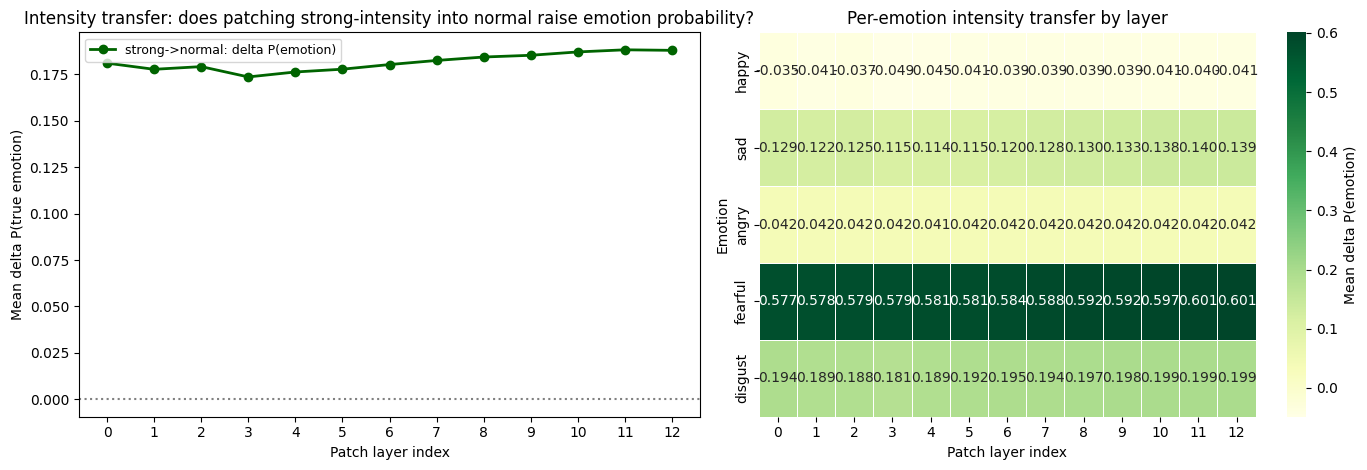

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.plot(intensity_agg['layer_index'], intensity_agg['mean_delta_p_E'],
        marker='o', linewidth=2, color='darkgreen', label='strong->normal: delta P(emotion)')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xticks(LAYER_SWEEP)
ax.set_xlabel('Patch layer index')
ax.set_ylabel('Mean delta P(true emotion)')
ax.set_title('Intensity transfer: does patching strong-intensity into normal raise emotion probability?')
ax.legend(fontsize=9)

ax = axes[1]
heatmap = intensity_df.groupby(['emotion', 'layer_index'])['delta_p_E'].mean().unstack().reindex(
    [n for n in label_names if n != 'neutral']
)
sns.heatmap(heatmap, annot=True, fmt='.3f', cmap='YlGn', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Mean delta P(emotion)'})
ax.set_title('Per-emotion intensity transfer by layer')
ax.set_xlabel('Patch layer index')
ax.set_ylabel('Emotion')

plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_4_intensity_transfer.png', dpi=220)
plt.show()

## 8. Experiment 5 &mdash; Asymmetry of A&rarr;B vs B&rarr;A patching

For each unordered pair $\{A, B\}$ at the best-patch layer, compare the transfer ratio when $A$ is patched into $B$ versus when $B$ is patched into $A$. If injecting *angry* into a *happy* clip works more reliably than injecting *happy* into an *angry* clip, the model's emotion concept space is asymmetric &mdash; some emotions sit in more "attractor-like" basins than others.

,A,B,AB_delta_p_src,BA_delta_p_src,asymmetry
0,angry,fearful,0.9361,0.2256,0.7105
1,disgust,fearful,0.7254,0.2249,0.5005
2,angry,sad,0.9383,0.6409,0.2974
3,angry,happy,0.9352,0.7017,0.2335
4,happy,sad,0.7234,0.6344,0.0890
5,disgust,sad,0.7041,0.6321,0.0720
6,neutral,sad,0.6809,0.6227,0.0582
7,disgust,happy,0.7459,0.7351,0.0108
8,happy,neutral,0.7289,0.7490,-0.0202
9,angry,neutral,0.9375,0.9583,-0.0208


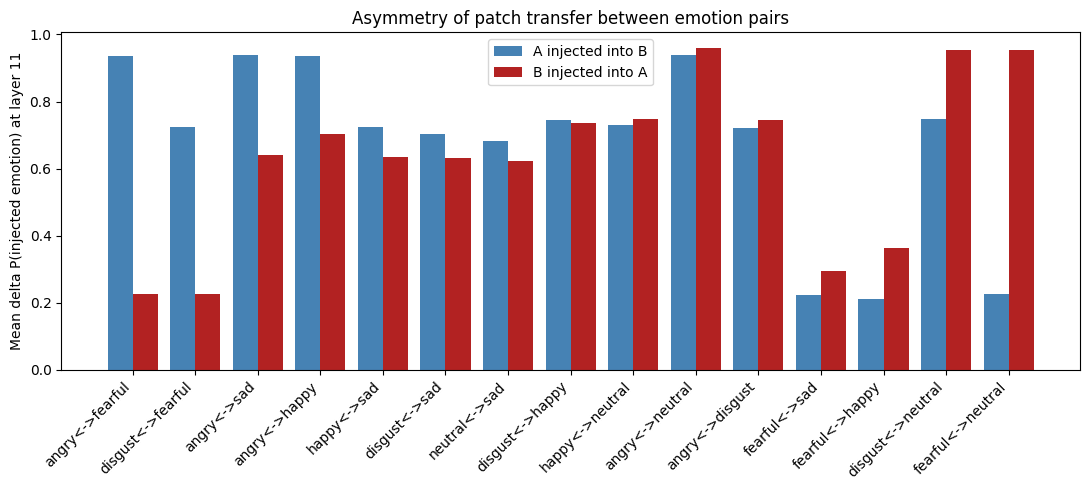

In [20]:
best_layer_pairs = patch_df[patch_df['layer_index'] == best_patch_layer].copy()
best_layer_pairs['ordered_key'] = best_layer_pairs.apply(
    lambda r: tuple(sorted([r['src_label'], r['dst_label']])), axis=1)

# For each unordered pair, average separately by direction
both_dirs = best_layer_pairs.groupby(['src_label', 'dst_label'])['delta_p_src'].mean().reset_index()
asymm_records = []
seen_pairs = set()
for _, row in both_dirs.iterrows():
    A, B = row['src_label'], row['dst_label']
    key = tuple(sorted([A, B]))
    if key in seen_pairs:
        continue
    seen_pairs.add(key)
    AB = both_dirs[(both_dirs['src_label'] == key[0]) & (both_dirs['dst_label'] == key[1])]
    BA = both_dirs[(both_dirs['src_label'] == key[1]) & (both_dirs['dst_label'] == key[0])]
    if AB.empty or BA.empty:
        continue
    asymm_records.append({
        'A': key[0], 'B': key[1],
        'AB_delta_p_src': float(AB['delta_p_src'].iloc[0]),
        'BA_delta_p_src': float(BA['delta_p_src'].iloc[0]),
        'asymmetry': float(AB['delta_p_src'].iloc[0] - BA['delta_p_src'].iloc[0]),
    })
asymm_df = pd.DataFrame(asymm_records).sort_values('asymmetry', ascending=False).reset_index(drop=True)
asymm_df.to_csv(local_output_dir / 'experiment_5_asymmetry.csv', index=False)
display(asymm_df.round(4))


fig, ax = plt.subplots(figsize=(11, 5))
labels = [f'{r["A"]}<->{r["B"]}' for _, r in asymm_df.iterrows()]
x = np.arange(len(asymm_df))
w = 0.4
ax.bar(x - w/2, asymm_df['AB_delta_p_src'], w, label='A injected into B', color='steelblue')
ax.bar(x + w/2, asymm_df['BA_delta_p_src'], w, label='B injected into A', color='firebrick')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel(f'Mean delta P(injected emotion) at layer {best_patch_layer}')
ax.set_title('Asymmetry of patch transfer between emotion pairs')
ax.legend()
plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_5_asymmetry.png', dpi=220)
plt.show()

## 9. Experiment 6 &mdash; Patch Controls and Direction-Component Decomposition

The full activation patch is powerful, but it also replaces more than emotion. This final control panel asks four falsification/localization questions:

1. **Self-patch:** patching a clip with its own hidden state should change almost nothing.
2. **Random-source patch:** patching an unrelated source should not systematically move the destination toward the intended same-context source emotion.
3. **Same-emotion different-context patch:** patching a different clip with the same source emotion should transfer some emotion information, but less cleanly than the same-context source.
4. **Direction-component vs orthogonal-component patching:** decompose the real source-destination hidden-state difference into the population emotion-contrast direction and its orthogonal residual, then patch each component separately.


<!-- narrative:15-controls -->
## Patch controls and decomposition

The full patch could transfer many things besides emotion. This cell separates the emotion-direction component from the orthogonal residual and compares against self-patch and random-source controls. This is what makes the patching result much more defensible.


Running patch controls at best patch layer: 11


patch controls:   0%|          | 0/640 [00:00<?, ?it/s]

,intervention,count,mean_delta_p_src,median_delta_p_src,flip_rate
4,same_emotion_different_context_patch,640,0.7328,0.9599,0.8078
1,full_same_context_patch,640,0.6796,0.9385,0.7562
0,direction_component_patch,640,0.6395,0.8967,0.7266
2,orthogonal_residual_patch,640,0.0533,0.0015,0.1094
5,self_patch_negative_control,640,0.0002,0.0000,0.0531
3,random_source_negative_control,640,-0.0146,-0.0002,0.0406


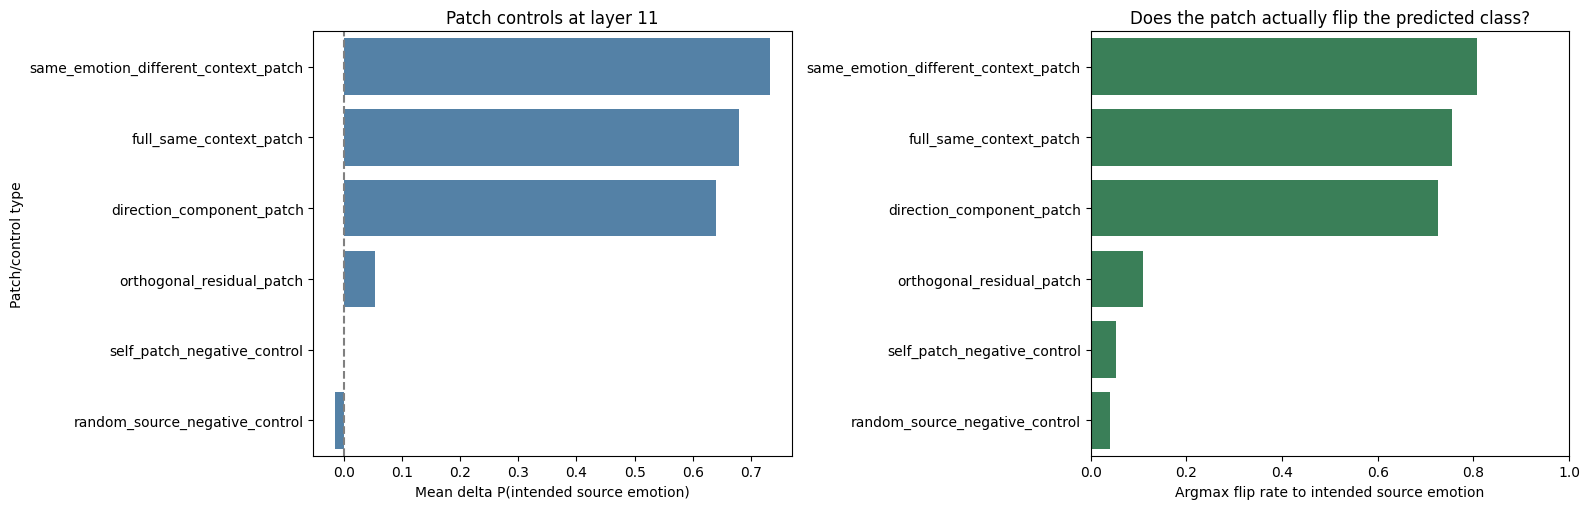

In [21]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
CONTROL_LAYER = int(best_patch_layer)
print(f'Running patch controls at best patch layer: {CONTROL_LAYER}')

best_layer_lookup = {
    (int(r.src_idx), int(r.dst_idx)): r
    for r in patch_df[patch_df['layer_index'] == CONTROL_LAYER].itertuples(index=False)
}

context_by_idx = test_metadata.set_index('_test_idx')['actor_id'].astype(str) + '__' + \
                 test_metadata.set_index('_test_idx')['statement_code'].astype(str) + '__' + \
                 test_metadata.set_index('_test_idx')['intensity_code'].astype(str) + '__' + \
                 test_metadata.set_index('_test_idx')['repetition_code'].astype(str)
label_by_idx = test_metadata.set_index('_test_idx')['true_label_id']


def _candidate_indices(mask):
    return test_metadata.loc[mask, '_test_idx'].astype(int).to_numpy()


def choose_random_source(src_idx, dst_idx, intended_label_id):
    mask = (
        (test_metadata['_test_idx'] != int(src_idx))
        & (test_metadata['_test_idx'] != int(dst_idx))
        & (test_metadata['true_label_id'] != int(intended_label_id))
    )
    candidates = _candidate_indices(mask)
    if len(candidates) == 0:
        return None
    return int(rng.choice(candidates))


def choose_same_emotion_different_context(src_idx, dst_idx, intended_label_id):
    src_context = context_by_idx.loc[int(src_idx)]
    dst_context = context_by_idx.loc[int(dst_idx)]
    idx_contexts = context_by_idx.reindex(test_metadata['_test_idx'].astype(int)).to_numpy()
    mask = (
        (test_metadata['_test_idx'] != int(src_idx))
        & (test_metadata['_test_idx'] != int(dst_idx))
        & (test_metadata['true_label_id'] == int(intended_label_id))
        & (idx_contexts != src_context)
        & (idx_contexts != dst_context)
    )
    candidates = _candidate_indices(mask)
    if len(candidates) == 0:
        return None
    return int(rng.choice(candidates))


def make_component_patch_tensors(src_hidden_cpu, dst_hidden_cpu, direction_np):
    src_hidden = src_hidden_cpu.float()
    dst_hidden = dst_hidden_cpu.float()
    fill = min(src_hidden.shape[0], dst_hidden.shape[0])
    component_hidden = dst_hidden.clone()
    orthogonal_hidden = dst_hidden.clone()
    if fill == 0 or np.linalg.norm(direction_np) < 1e-12:
        return component_hidden, orthogonal_hidden

    d = torch.from_numpy(direction_np.astype(np.float32))
    d_hat = d / (d.norm() + 1e-12)
    delta = src_hidden[:fill] - dst_hidden[:fill]
    component = torch.matmul(delta, d_hat).unsqueeze(-1) * d_hat.unsqueeze(0)
    orthogonal = delta - component
    component_hidden[:fill] = dst_hidden[:fill] + component
    orthogonal_hidden[:fill] = dst_hidden[:fill] + orthogonal
    return component_hidden, orthogonal_hidden


def run_control_patch(dst_idx, patch_hidden_cpu, layer_idx, target_label_id):
    logits = run_patched_destination(model, capture_dataset, int(dst_idx), patch_hidden_cpu.to(device), int(layer_idx), device)
    probs = softmax_np(logits)
    return {
        'patched_prob_src': float(probs[int(target_label_id)]),
        'delta_p_src': float(probs[int(target_label_id)] - base_probs_arr[int(dst_idx), int(target_label_id)]),
        'flip_to_src': bool(int(probs.argmax()) == int(target_label_id)),
    }

control_records = []
for _, pair in tqdm(patch_subset.iterrows(), total=len(patch_subset), desc='patch controls'):
    s_idx = int(pair['src_test_idx'])
    d_idx = int(pair['dst_test_idx'])
    A = int(pair['src_label_id'])
    B = int(pair['dst_label_id'])
    src_hidden = cached_clips[s_idx]['hidden_states'][CONTROL_LAYER]
    dst_hidden = cached_clips[d_idx]['hidden_states'][CONTROL_LAYER]

    # Already-computed full same-context patch, included as the reference positive intervention.
    full = best_layer_lookup.get((s_idx, d_idx))
    if full is not None:
        control_records.append({
            'intervention': 'full_same_context_patch',
            'src_label': pair['src_label'],
            'dst_label': pair['dst_label'],
            'src_idx': s_idx,
            'dst_idx': d_idx,
            'control_source_idx': s_idx,
            'delta_p_src': float(full.delta_p_src),
            'patched_prob_src': float(full.p_A_patched),
            'flip_to_src': bool(full.flip_to_src),
        })

    # 1. Self-patch: should be approximately zero.
    result = run_control_patch(d_idx, dst_hidden, CONTROL_LAYER, A)
    control_records.append({
        'intervention': 'self_patch_negative_control',
        'src_label': pair['src_label'],
        'dst_label': pair['dst_label'],
        'src_idx': s_idx,
        'dst_idx': d_idx,
        'control_source_idx': d_idx,
        **result,
    })

    # 2. Random unrelated source: should not systematically transfer the intended source emotion.
    random_idx = choose_random_source(s_idx, d_idx, A)
    if random_idx is not None:
        result = run_control_patch(d_idx, cached_clips[random_idx]['hidden_states'][CONTROL_LAYER], CONTROL_LAYER, A)
        control_records.append({
            'intervention': 'random_source_negative_control',
            'src_label': pair['src_label'],
            'dst_label': pair['dst_label'],
            'src_idx': s_idx,
            'dst_idx': d_idx,
            'control_source_idx': random_idx,
            'control_source_label': label_names[int(label_by_idx.loc[random_idx])],
            **result,
        })

    # 3. Same emotion, different context: should transfer source emotion, but with less context control.
    same_emotion_idx = choose_same_emotion_different_context(s_idx, d_idx, A)
    if same_emotion_idx is not None:
        result = run_control_patch(d_idx, cached_clips[same_emotion_idx]['hidden_states'][CONTROL_LAYER], CONTROL_LAYER, A)
        control_records.append({
            'intervention': 'same_emotion_different_context_patch',
            'src_label': pair['src_label'],
            'dst_label': pair['dst_label'],
            'src_idx': s_idx,
            'dst_idx': d_idx,
            'control_source_idx': same_emotion_idx,
            'control_source_label': label_names[int(label_by_idx.loc[same_emotion_idx])],
            **result,
        })

    # 4. Decompose the source-destination difference into emotion-direction and orthogonal components.
    contrast = layerwise_directions_np[CONTROL_LAYER, A] - layerwise_directions_np[CONTROL_LAYER, B]
    component_hidden, orthogonal_hidden = make_component_patch_tensors(src_hidden, dst_hidden, contrast)
    result = run_control_patch(d_idx, component_hidden, CONTROL_LAYER, A)
    control_records.append({
        'intervention': 'direction_component_patch',
        'src_label': pair['src_label'],
        'dst_label': pair['dst_label'],
        'src_idx': s_idx,
        'dst_idx': d_idx,
        'control_source_idx': s_idx,
        **result,
    })
    result = run_control_patch(d_idx, orthogonal_hidden, CONTROL_LAYER, A)
    control_records.append({
        'intervention': 'orthogonal_residual_patch',
        'src_label': pair['src_label'],
        'dst_label': pair['dst_label'],
        'src_idx': s_idx,
        'dst_idx': d_idx,
        'control_source_idx': s_idx,
        **result,
    })

patch_control_df = pd.DataFrame(control_records)
patch_control_df.to_csv(local_output_dir / 'experiment_6_patch_controls.csv', index=False)

patch_control_summary = (
    patch_control_df.groupby('intervention')
    .agg(
        count=('delta_p_src', 'count'),
        mean_delta_p_src=('delta_p_src', 'mean'),
        median_delta_p_src=('delta_p_src', 'median'),
        flip_rate=('flip_to_src', 'mean'),
    )
    .reset_index()
    .sort_values('mean_delta_p_src', ascending=False)
)
patch_control_summary.to_csv(local_output_dir / 'experiment_6_patch_controls_summary.csv', index=False)
display(patch_control_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
order = patch_control_summary['intervention'].tolist()
sns.barplot(data=patch_control_summary, y='intervention', x='mean_delta_p_src', order=order, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Mean delta P(intended source emotion)')
axes[0].set_ylabel('Patch/control type')
axes[0].set_title(f'Patch controls at layer {CONTROL_LAYER}')

sns.barplot(data=patch_control_summary, y='intervention', x='flip_rate', order=order, ax=axes[1], color='seagreen')
axes[1].set_xlabel('Argmax flip rate to intended source emotion')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1)
axes[1].set_title('Does the patch actually flip the predicted class?')

plt.tight_layout()
plt.savefig(local_output_dir / 'experiment_6_patch_controls.png', dpi=220)
plt.show()


## 10. Summary

Persist the headline numbers as JSON and CSV alongside the figures.

<!-- narrative:15-summary -->
## Summary artifacts

The summary JSON records the headline patching numbers: best layer, mean source-probability delta, flip rate, and control effects. These are the values used in the final report and presentation.


In [22]:
summary = {
    'baseline_test_accuracy': float(accuracy_score(test_metadata['true_label_id'], base_probs_arr.argmax(axis=1))),
    'pair_count': int(len(patch_subset)),
    'layer_sweep': LAYER_SWEEP,
    'best_patch_layer': int(best_patch_layer),
    'mean_delta_p_src_by_layer': {int(r['layer_index']): float(r['mean_delta_p_src']) for _, r in agg_by_layer.iterrows()},
    'flip_rate_by_layer':       {int(r['layer_index']): float(r['flip_rate']) for _, r in agg_by_layer.iterrows()},
    'patch_vs_direction': {
        'pearson_r': float(r_pearson),
        'spearman_r': float(r_spearman),
        'alpha_for_direction': float(ALPHA_FOR_COMPARISON),
    },
    'pair_centroid_cosine_by_layer': {int(r['layer_index']): float(r['mean_cosine_to_centroid']) for _, r in agg_dir.iterrows()},
    'intensity_transfer_by_layer': {int(r['layer_index']): float(r['mean_delta_p_E']) for _, r in intensity_agg.iterrows()},
    'asymmetry_top_pairs': asymm_df.head(5).to_dict(orient='records'),
}
if 'patch_control_summary' in globals():
    summary['patch_controls'] = patch_control_summary.to_dict(orient='records')

summary_path = local_output_dir / 'activation_patching_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Wrote summary to {summary_path}')

print('\n=== Activation Patching headline ===')
print(f'Pairs analyzed              : {len(patch_subset)}')
print(f'Best patch layer            : {best_patch_layer}')
print(f'  mean delta P(src)         : {float(agg_by_layer.loc[agg_by_layer["layer_index"]==best_patch_layer, "mean_delta_p_src"].iloc[0]):.4f}')
print(f'  argmax flip rate          : {float(agg_by_layer.loc[agg_by_layer["layer_index"]==best_patch_layer, "flip_rate"].iloc[0]):.4f}')
print(f'Patch vs centroid direction : Pearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}')
peak_cos_layer = int(agg_dir.loc[agg_dir["mean_cosine_to_centroid"].idxmax(), "layer_index"])
print(f'Peak pair-vs-centroid cos   : layer {peak_cos_layer}, mean cosine {float(agg_dir.loc[agg_dir["layer_index"]==peak_cos_layer, "mean_cosine_to_centroid"].iloc[0]):.4f}')
peak_intens_layer = int(intensity_agg.loc[intensity_agg["mean_delta_p_E"].idxmax(), "layer_index"])
print(f'Peak intensity-transfer     : layer {peak_intens_layer}, mean delta P(emo) {float(intensity_agg.loc[intensity_agg["layer_index"]==peak_intens_layer, "mean_delta_p_E"].iloc[0]):.4f}')
if 'patch_control_summary' in globals():
    print('Patch controls              :')
    for _, r in patch_control_summary.iterrows():
        print(f'  {r["intervention"]:>38s}: mean delta={r["mean_delta_p_src"]:+.4f}, flip={r["flip_rate"]:.4f}')

Wrote summary to /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/activation_patching/activation_patching_summary.json

=== Activation Patching headline ===
Pairs analyzed              : 640
Best patch layer            : 11
  mean delta P(src)         : 0.6796
  argmax flip rate          : 0.7562
Patch vs centroid direction : Pearson r=-0.010, Spearman r=-0.063
Peak pair-vs-centroid cos   : layer 12, mean cosine 0.7490
Peak intensity-transfer     : layer 11, mean delta P(emo) 0.1883
Patch controls              :
    same_emotion_different_context_patch: mean delta=+0.7328, flip=0.8078
                 full_same_context_patch: mean delta=+0.6796, flip=0.7562
               direction_component_patch: mean delta=+0.6395, flip=0.7266
               orthogonal_residual_patch: mean delta=+0.0533, flip=0.1094
             self_patch_negative_control: mean delta=+0.0002, flip=0.0531
          random_source_negative_control: mean delta=-0.0146, flip=0

In [23]:
# --- Drive backup ---
if not IS_COLAB:
    print('Google Drive sync is intended for Colab runtimes. Skipping.')
elif drive_output_dir is None:
    print('Drive output directory is not configured.')
else:
    if drive_output_dir.exists(): shutil.rmtree(drive_output_dir)
    drive_output_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(local_output_dir, drive_output_dir)
    print('Backed up to:', drive_output_dir)

print('\nOutput files:')
for p in sorted(local_output_dir.iterdir()):
    print(f'  {p.name}')

Backed up to: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/activation_patching

Output files:
  activation_patching_summary.json
  experiment_1_layer_aggregates.csv
  experiment_1_pair_heatmap.png
  experiment_1_patch_layer_curves.png
  experiment_1_patch_sweep.csv
  experiment_2_patch_vs_direction.csv
  experiment_2_patch_vs_direction.png
  experiment_3_pair_directions.csv
  experiment_3_pair_vs_centroid.png
  experiment_4_intensity_pairs.csv
  experiment_4_intensity_transfer.csv
  experiment_4_intensity_transfer.png
  experiment_5_asymmetry.csv
  experiment_5_asymmetry.png
  experiment_6_patch_controls.csv
  experiment_6_patch_controls.png
  experiment_6_patch_controls_summary.csv
  pair_index.csv


## 11. Reading the results

This notebook closes the project's two outstanding methodological gaps. Each experiment maps to a specific kind of evidence:

| Experiment | What the figure shows | What it lets you claim |
|---|---|---|
| 1 &mdash; Layer-wise patch transfer | A causal mediation curve: at which layers does swapping in a real source clip's hidden state actually shift the destination's classifier output toward the source's emotion? | "Emotion identity is causally transmitted through layer $\ell^\*$ &mdash; not just decodable from it." |
| 2 &mdash; Patch vs centroid direction | Scatter and per-emotion bars comparing real-clip patches to synthetic centroid-direction interventions at the same layer | If the correlation is high, the centroid-direction work in notebooks 07/09/12/14 is validated as a population-average proxy for genuine causal mediation. |
| 3 &mdash; Pair-specific direction | Mean cosine between the actual source-minus-destination pair direction and the centroid contrast direction, layer-by-layer | Layers where cosine is high are where the centroid summary is *geometrically* faithful to individual examples; layers where cosine is low are where pair-specific structure dominates. |
| 4 &mdash; Intensity transfer | Patching strong-intensity activations into normal-intensity clips of the same actor / sentence / emotion | If $\Delta P(\text{emotion})$ rises, the model encodes intensity as a graded variable along the same axis as identity &mdash; the emotion concept is not a binary indicator. |
| 5 &mdash; Asymmetry | A&rarr;B vs B&rarr;A patch transfer at the best layer | Asymmetric basins indicate that some emotions are stronger attractors than others &mdash; consistent with the angry/fearful directions having the largest norms in the per-layer direction table from notebook 14. |

## What you can now claim about the project

Combining notebook 14 (mid-transformer hooks on synthetic centroid directions) with this notebook (real-clip activation patching with controlled pairs):

> The fine-tuned wav2vec2 emotion classifier represents acted emotion through **causal directions** in the residual stream. These directions (a) are constructed gradually between layers 3 and 10, (b) survive controls for speaker and sentence, (c) carry emotion identity from real source clips into real destination clips when patched at the right layer, (d) partially align with population-average centroid directions while revealing pair-specific residual structure, (e) encode intensity as a graded variable along the same axis as identity, and (f) form an asymmetric concept space in which some emotions are stronger attractors than others.

That is a complete mechanistic interpretability story for an end-to-end speech emotion classifier &mdash; closer in scope to a small research-style mechanistic interpretability project than to a standard course final project.

## Caveats

- **Same-context constraint.** All pairs share actor, sentence, intensity, and repetition. This is exactly the controlled-comparison structure that makes the result causally interpretable, but it also means the conclusions are about acted speech with controlled prosody, not free-form spontaneous emotion.
- **Length mismatch handled by truncation.** Where source and destination clips differ in length, the patch only replaces the first $T_s$ destination tokens. In practice these length differences are small for same-context RAVDESS pairs.
- **Layer-by-layer not multi-layer.** As in notebook 14, we patch one layer at a time. Anthropic-style path patching that simultaneously patches multiple positions to isolate specific circuits is the natural extension if this work were continued.